# Fashion MNIST: Visualization Examples



## 0. Setup



In [1]:
import gzip
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Download & parse the raw IDX files with NumPy

In [2]:
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"

def fetch(filename):
    """Download a file if not already cached locally."""
    path = f"/tmp/{filename}"
    try:
        with open(path, 'rb') as f:
            return f.read()
    except FileNotFoundError:
        with urllib.request.urlopen(BASE_URL + filename) as resp:
            data = resp.read()
        with open(path, 'wb') as f:
            f.write(data)
        return data

def load_images(filename):
    raw = gzip.decompress(fetch(filename))
    n = int.from_bytes(raw[4:8], 'big')
    rows = int.from_bytes(raw[8:12], 'big')
    cols = int.from_bytes(raw[12:16], 'big')
    return np.frombuffer(raw, dtype=np.uint8, offset=16).reshape(n, rows, cols)

def load_labels(filename):
    raw = gzip.decompress(fetch(filename))
    return np.frombuffer(raw, dtype=np.uint8, offset=8)

X_train = load_images('train-images-idx3-ubyte.gz')
y_train = load_labels('train-labels-idx1-ubyte.gz')

print("Images:", X_train.shape)   # (60000, 28, 28)
print("Labels:", y_train.shape)   # (60000,)
print("Pixel value range:", X_train.min(), "-", X_train.max())


Images: (60000, 28, 28)
Labels: (60000,)
Pixel value range: 0 - 255


### Load into a pandas DataFrame

Each 28x28 image is flattened into 784 pixel columns, one row per image — the standard tabular representation for this kind of data.

In [3]:
n_samples = 60000  # subsample for speed; UMAP/plotting all 60,000 isn't necessary for this demo

rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), size=n_samples, replace=False)

X_sample = X_train[idx]
y_sample = y_train[idx]

pixel_cols = [f'pixel_{i}' for i in range(784)]
df = pd.DataFrame(X_sample.reshape(n_samples, -1), columns=pixel_cols)
df['label'] = y_sample
df['category'] = df['label'].map(dict(enumerate(CLASS_NAMES)))

print(df.shape)
df[['label', 'category'] + pixel_cols[:5]].head()


(60000, 786)


,label,category,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4
0,7,Sneaker,0,0,0,0,0
1,8,Bag,0,0,0,0,0
2,8,Bag,0,0,0,0,0
3,8,Bag,0,0,0,0,0
4,1,Trouser,0,0,0,0,0


### Quick look: one example image per category

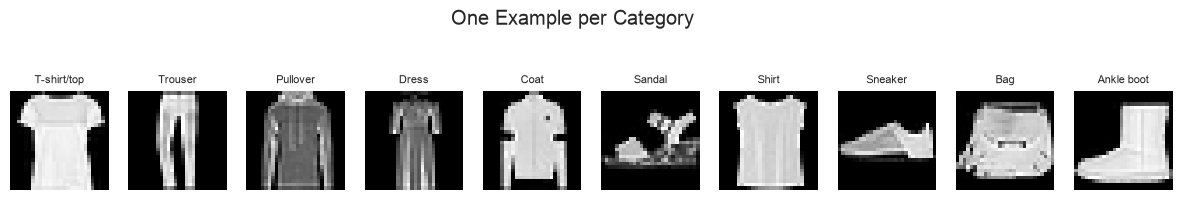

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for class_id, ax in enumerate(axes):
    example = X_sample[y_sample == class_id][0]
    ax.imshow(example, cmap='gray')
    ax.set_title(CLASS_NAMES[class_id], fontsize=8)
    ax.axis('off')
plt.suptitle('One Example per Category', y=1.15)
plt.show()


## Question 4: UMAP

Draw a UMAP 2D with 60000 data points from Fashion MNIST dataset. Use the provided skeleton code
for data loading and pre-processing (Fashion_MNIST_Visualization_Examples.ipynb). Use them and then
do the UMAP for 10 classes in the same way we did in class.

In [8]:
import umap

X = df[pixel_cols].values
y = df['label'].values

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

/Users/maddox/progz/CS-523/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


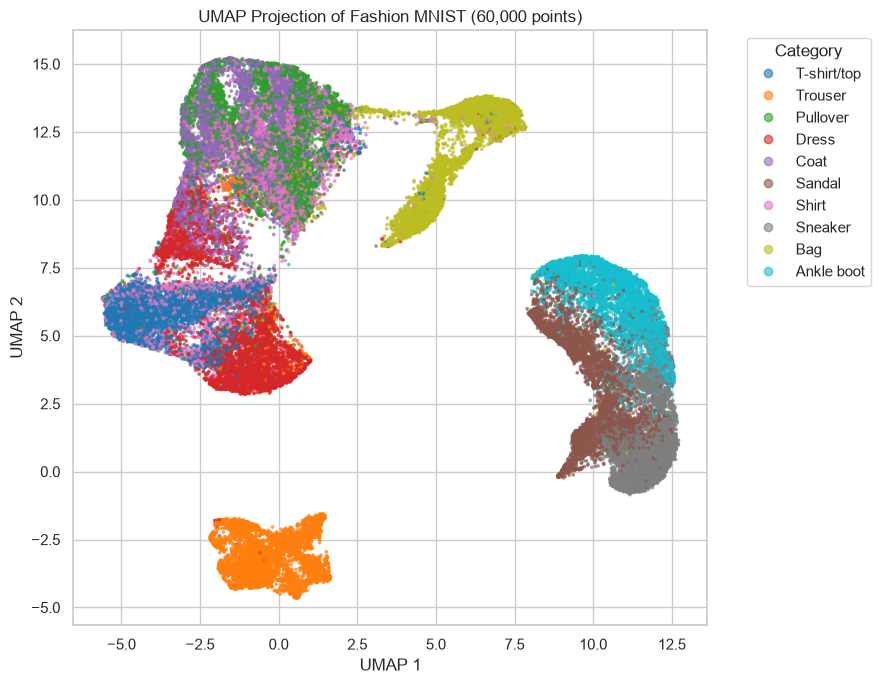

In [10]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=3, alpha=0.6)
plt.legend(handles=scatter.legend_elements()[0], labels=CLASS_NAMES, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Projection of Fashion MNIST (60,000 points)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

Draw a UMAP 2D with 5000 data points similar to the above with 60K points.

In [11]:
n_samples = 5000

rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), size=n_samples, replace=False)

X_sample = X_train[idx]
y_sample = y_train[idx]

pixel_cols = [f'pixel_{i}' for i in range(784)]
df = pd.DataFrame(X_sample.reshape(n_samples, -1), columns=pixel_cols)
df['label'] = y_sample
df['category'] = df['label'].map(dict(enumerate(CLASS_NAMES)))

print(df.shape)
df[['label', 'category'] + pixel_cols[:5]].head()

(5000, 786)


,label,category,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4
0,3,Dress,0,0,0,0,0
1,4,Coat,0,0,0,0,0
2,0,T-shirt/top,0,0,0,0,0
3,2,Pullover,0,0,0,0,0
4,1,Trouser,0,0,0,0,0


In [12]:
X = df[pixel_cols].values
y = df['label'].values

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

/Users/maddox/progz/CS-523/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


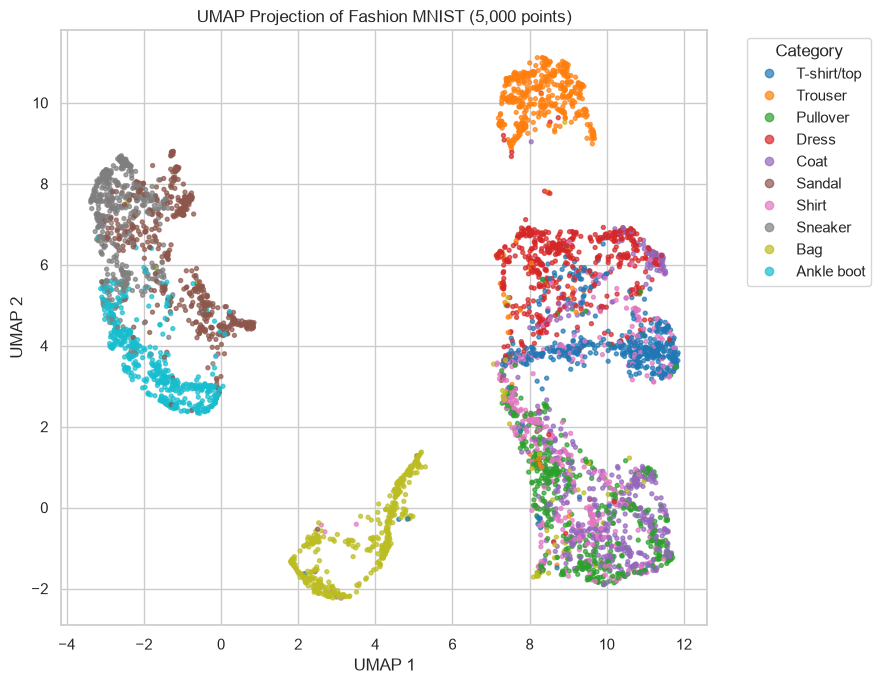

In [15]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='tab10', s=8, alpha=0.7)
plt.legend(handles=scatter2.legend_elements()[0], labels=CLASS_NAMES, title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Projection of Fashion MNIST (5,000 points)')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

**How many clusters do you see in each UMAPs? Is there any differences in those 2 plots? Which of the 2
classes show quite distinct clusters compared to other 8 classes?**

Both plots show about 5 or 6 visually separable clusters and several overlapping clusters. Both plots have the same overall shape, the 60k plot is much denser so the mixing of some of the clusters is easier to see. The 5k plot is more separated and noisy but show the same groupings. This shows that the structure is the same regardless of the number of samples. The 5k plot is roughly mirrored left to right and top to bottom, but the shapes of the clusters are the same as the 60k plot. The Trouser and Bag categories are the most distinct, forming clean, isolated clusters. The other 8 categories overlap with at least one other, this is because their pixel shapes are more similar in the pixel space.

## Question 5: Visualize with Heatmap

Using the 60000-row, group the data by label (0-9), and for each group, compute the mean of all 784
pixel columns. This gives you a single 784-value "average image" per category.

In [27]:
avg_images = df.groupby('label')[pixel_cols].mean()

Reshape each category’s 784 mean values back into a 28x28 grid with .to_numpy().reshape(28, 28).

In [28]:
avg_grids = {label: avg_images.loc[label].to_numpy().reshape(28, 28) for label in avg_images.index}

Build a 2×5 grid of subplots (plt.subplots(2, 5, figsize=(14, 6))), and inside a loop over the class IDs,
display each category's mean image using sns.heatmap() with cmap='viridis', no colorbar (cbar=False),
and no tick labels (xticklabels=False, yticklabels=False).

Title each subplot with its class name (CLASS_NAMES[class_id]), and give the whole figure a shared
title with plt.suptitle(...).

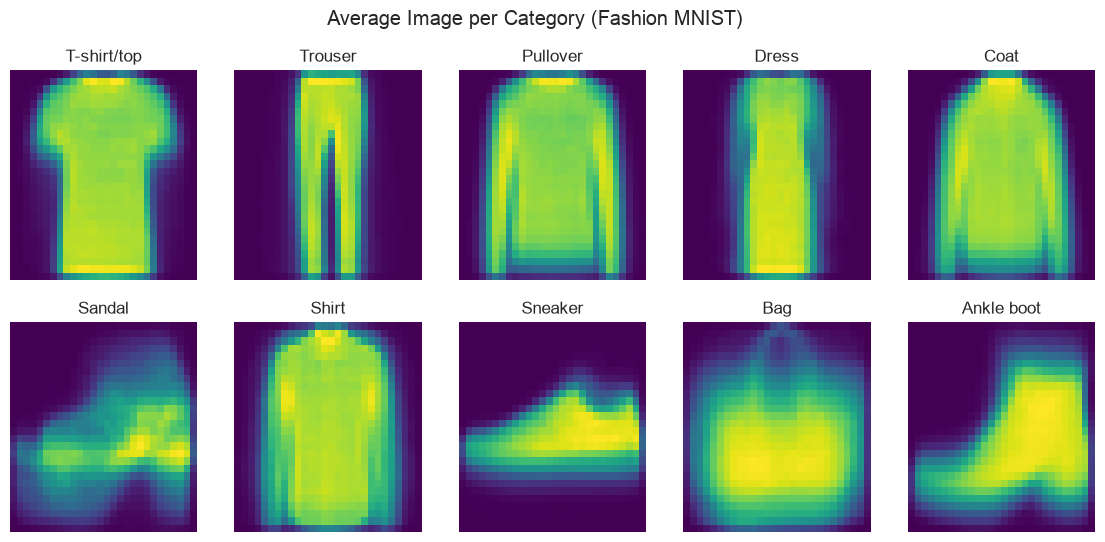

In [33]:
fig, axs = plt.subplots(2, 5, figsize=(14, 6))

for class_id, ax in zip(range(10), axs.flat):
    sns.heatmap(avg_grids[class_id], cmap='viridis', cbar=False, xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title(CLASS_NAMES[class_id])

plt.suptitle('Average Image per Category (Fashion MNIST)')
plt.show()

**How many plots do you get?**

10 plots, one for each class.

## Question 6: Boxplot: Average Brightness by Class Category

Create a boxplot of average pixel brightness of the Fashion MNIST dataset classes.

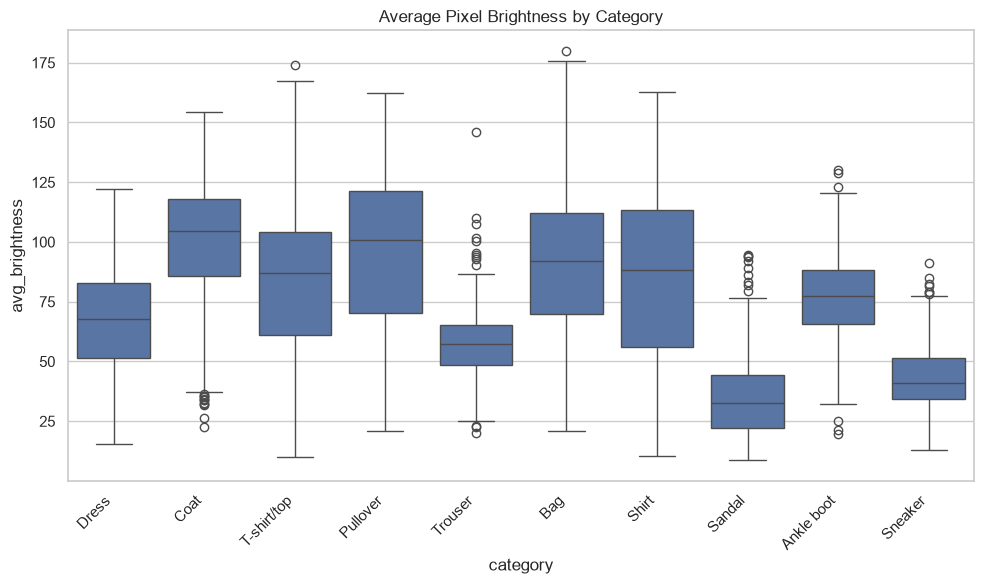

In [34]:
df['avg_brightness'] = df[pixel_cols].mean(axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='avg_brightness')
plt.xticks(rotation=45, ha='right')
plt.title('Average Pixel Brightness by Category')
plt.tight_layout()
plt.show()

Order top 3 and lowest 2 classes in brightness dustrubution. Does this ranking make visual sense given
what these images typically look like (recall the mean-image heatmap from earlier)? Why full-body items
would average brighter than footwear items on a black background.

In [35]:
medians = df.groupby('category')['avg_brightness'].median().sort_values(ascending=False)
print(medians)

category
Coat           104.401786
Pullover       100.729592
Bag             92.038265
Shirt           88.265306
T-shirt/top     86.900510
Ankle boot      77.351403
Dress           67.848214
Trouser         57.395408
Sneaker         41.033163
Sandal          32.752551
Name: avg_brightness, dtype: float64


The top 3 brightest classes are Coat, Pullover, and Bag, and the lowest 2 are Sandal and Sneaker. This matches the mean-image heatmaps. Coats and pullovers fill most of the frame, so most pixels are bright. Sandals and sneakers are much smaller, so most of the frame is still black background, pulling the average down even though the shoe itself is bright where it exists.

**Which one has the widest brightness, why?**

Shirt has the widest brightness, this is likely the case because shirts have the most variation in style, sleeve length, pattern, and color within a class, so how much of the frame is filled and how bright it is varies between images, unlike something like Sandals or Trousers which are more consistent across examples.